In [3]:
# Operating system functions (file and folder handling)
import os

# ZIP file extraction library
import zipfile

# Used to measure training time
import time

# Numerical computing library
import numpy as np

# Data visualization and plotting library
import matplotlib.pyplot as plt

# TensorFlow deep learning framework
import tensorflow as tf

# Keras layers and model creation tools
from tensorflow.keras import layers, models

# Image preprocessing and data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Measures how many predicted positive samples are correct
from sklearn.metrics import precision_score

# Measures how many actual positive samples are correctly identified
from sklearn.metrics import recall_score

# Harmonic mean of Precision and Recall
from sklearn.metrics import f1_score

# Displays classification performance
from sklearn.metrics import confusion_matrix

# Visualization of confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Includes Precision, Recall and F1-score
from sklearn.metrics import classification_report

# Used to evaluate classification performance
from sklearn.metrics import roc_curve, auc

# Used for image loading and processing
from PIL import Image

# Confirmation message
print("All libraries imported successfully")

All libraries imported successfully


In [4]:
## Path to ZIP file
zip_path = "/content/archive.zip"

# Check if ZIP file exists
if os.path.exists(zip_path):

    print("ZIP file found.")

    # Extract ZIP file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

    print("Dataset extracted successfully")

else:
    print("archive.zip not found!")

ZIP file found.
Dataset extracted successfully


In [11]:
# Image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Batch size
BATCH_SIZE = 32

# Data augmentation for training dataset
# Augmentation improves generalization and reduces overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and testing datasets only normalized
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training dataset
train_data = train_datagen.flow_from_directory(
    '/content/Quality Dataset/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# Load validation dataset
val_data = val_test_datagen.flow_from_directory(
    '/content/Quality Dataset/valid',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Load testing dataset
test_data = val_test_datagen.flow_from_directory(
    '/content/Quality Dataset/test',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Display dataset information
print("\n Dataset Loaded Successfully")
print(f"Class Labels: {train_data.class_indices}")

print(f"\nTraining Images: {train_data.samples}")
print(f"Validation Images: {val_data.samples}")
print(f"Testing Images: {test_data.samples}")


Found 287 images belonging to 2 classes.
Found 48 images belonging to 2 classes.
Found 24 images belonging to 2 classes.

 Dataset Loaded Successfully
Class Labels: {'fresh': 0, 'rotten': 1}

Training Images: 287
Validation Images: 48
Testing Images: 24


In [13]:
# Function for creating CNN architecture
def create_cnn_model():

    # Create Sequential CNN model
    model = models.Sequential([

        # First Convolution Layer
        layers.Conv2D(
            32,
            (3, 3),
            activation='relu',
            input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        ),

        # First Max Pooling Layer
        layers.MaxPooling2D(2, 2),

        # Second Convolution Layer
        layers.Conv2D(
            64,
            (3, 3),
            activation='relu'
        ),

        # Second Max Pooling Layer
        layers.MaxPooling2D(2, 2),

        # Third Convolution Layer
        layers.Conv2D(
            128,
            (3, 3),
            activation='relu'
        ),

        # Third Max Pooling Layer
        layers.MaxPooling2D(2, 2),

        # Flatten layer
        layers.Flatten(),

        # Dense hidden layer
        layers.Dense(128, activation='relu'),

        # Dropout regularization
        layers.Dropout(0.5),

        # Second dense layer
        layers.Dense(64, activation='relu'),

        # Dropout regularization
        layers.Dropout(0.3),

        # Output layer for binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile CNN model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# Create CNN model
cnn_model = create_cnn_model()

# Display CNN architecture summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Start training timer
start_time = time.time()

# Train CNN model
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,  # Small dataset (287 images) - prevents overfitting
    verbose=1
)

# End training timer
cnn_training_time = time.time() - start_time

print(f"\n CNN Training Completed")
print(f"Training Time: {cnn_training_time:.2f} seconds")

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.5192 - loss: 1.0083 - val_accuracy: 0.6458 - val_loss: 0.6896
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.4983 - loss: 0.7084 - val_accuracy: 0.6250 - val_loss: 0.6750
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5854 - loss: 0.6732 - val_accuracy: 0.5417 - val_loss: 0.6252
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6516 - loss: 0.6345 - val_accuracy: 0.6458 - val_loss: 0.6171
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5923 - loss: 0.6324 - val_accuracy: 0.6667 - val_loss: 0.5864
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.6551 - loss: 0.6105 - val_accuracy: 0.6667 - val_loss: 0.5256
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.6655 - loss: 0.6143 - val_accuracy: 0.6458 - val_loss: 0.5808
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7526 - loss: 0.5614 - val_accuracy: 0.7708 - val_loss: 0.5869
Epoch 9/

In [15]:
print("CNN MODEL EVALUATION")

# Evaluate CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_data)

print(f"CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Test Loss: {cnn_loss:.4f}")


CNN MODEL EVALUATION
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7083 - loss: 0.5812
CNN Test Accuracy: 0.7083
CNN Test Loss: 0.5812


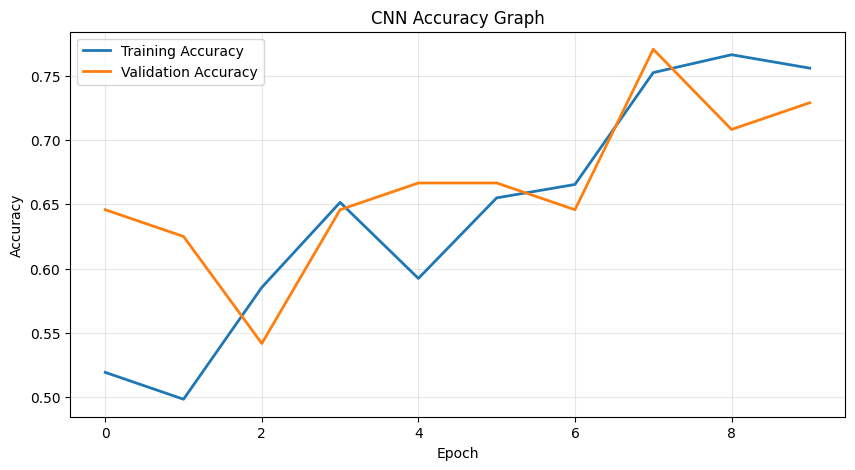

In [16]:
plt.figure(figsize=(10, 5))

# Training accuracy
plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

# Validation accuracy
plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title('CNN Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
# Load pre-trained MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model.trainable = False

print(f"Frozen Layers: {len(base_model.layers)}")

# Build complete MobileNetV2 model
mobilenet_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

# Compile MobileNetV2 model
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Frozen Layers: 154


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Start timer
start_time = time.time()

# Train model
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,   # Pre-trained model needs fewer epochs than CNN
    verbose=1
)

# End timer
mobilenet_training_time = time.time() - start_time

print(f"\n MobileNetV2 Training Completed")
print(f"Training Time: {mobilenet_training_time:.2f} seconds")


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.7143 - loss: 0.5671 - val_accuracy: 0.8542 - val_loss: 0.3673
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7840 - loss: 0.4623 - val_accuracy: 0.7708 - val_loss: 0.4833
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8780 - loss: 0.3091 - val_accuracy: 0.8333 - val_loss: 0.3619
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9024 - loss: 0.2201 - val_accuracy: 0.8958 - val_loss: 0.2916
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9477 - loss: 0.1447 - val_accuracy: 0.8542 - val_loss: 0.3766
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9477 - loss: 0.1279 - val_accuracy: 0.8958 - val_loss: 0.3297
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9617 - loss: 0.1023 - val_accuracy: 0.8333 - val_loss: 0.4253
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9756 - loss: 0.1024 - val_accuracy: 0.8750 - val_loss: 0.3045
Epoch 9/

In [19]:
# Evaluate model
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_data)

print(f"MobileNetV2 Accuracy: {mobilenet_accuracy:.4f}")
print(f"MobileNetV2 Loss: {mobilenet_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step - accuracy: 0.8333 - loss: 0.3597
MobileNetV2 Accuracy: 0.8333
MobileNetV2 Loss: 0.3597


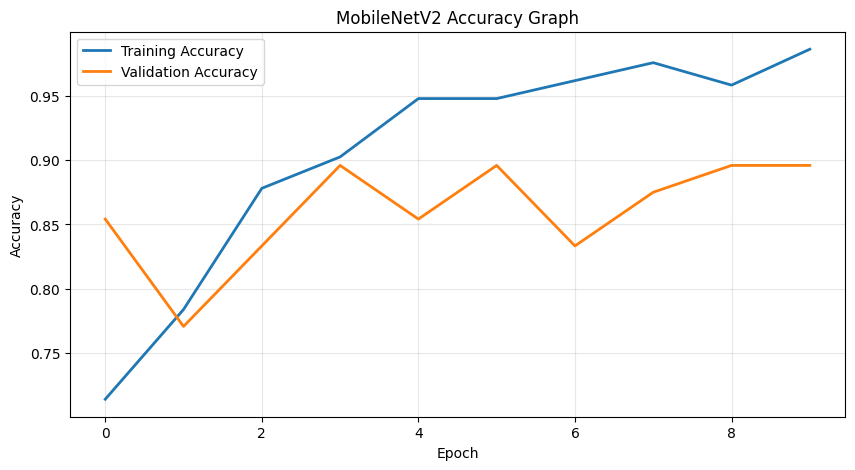

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    mobilenet_history.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    mobilenet_history.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title('MobileNetV2 Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
# True labels
y_true = test_data.labels

# CNN predictions
y_pred_cnn_probs = cnn_model.predict(test_data)
y_pred_cnn = (y_pred_cnn_probs > 0.5).astype(int).flatten()

# MobileNetV2 predictions
y_pred_mobile_probs = mobilenet_model.predict(test_data)
y_pred_mobile = (y_pred_mobile_probs > 0.5).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [22]:
# CNN metrics
cnn_precision = precision_score(y_true, y_pred_cnn)
cnn_recall = recall_score(y_true, y_pred_cnn)
cnn_f1 = f1_score(y_true, y_pred_cnn)

# MobileNetV2 metrics
mobile_precision = precision_score(y_true, y_pred_mobile)
mobile_recall = recall_score(y_true, y_pred_mobile)
mobile_f1 = f1_score(y_true, y_pred_mobile)

print("\nCNN Metrics")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1-Score : {cnn_f1:.4f}")

print("\nMobileNetV2 Metrics")
print(f"Accuracy : {mobilenet_accuracy:.4f}")
print(f"Precision: {mobile_precision:.4f}")
print(f"Recall   : {mobile_recall:.4f}")
print(f"F1-Score : {mobile_f1:.4f}")


CNN Metrics
Accuracy : 0.7083
Precision: 0.8571
Recall   : 0.5000
F1-Score : 0.6316

MobileNetV2 Metrics
Accuracy : 0.8333
Precision: 1.0000
Recall   : 0.6667
F1-Score : 0.8000


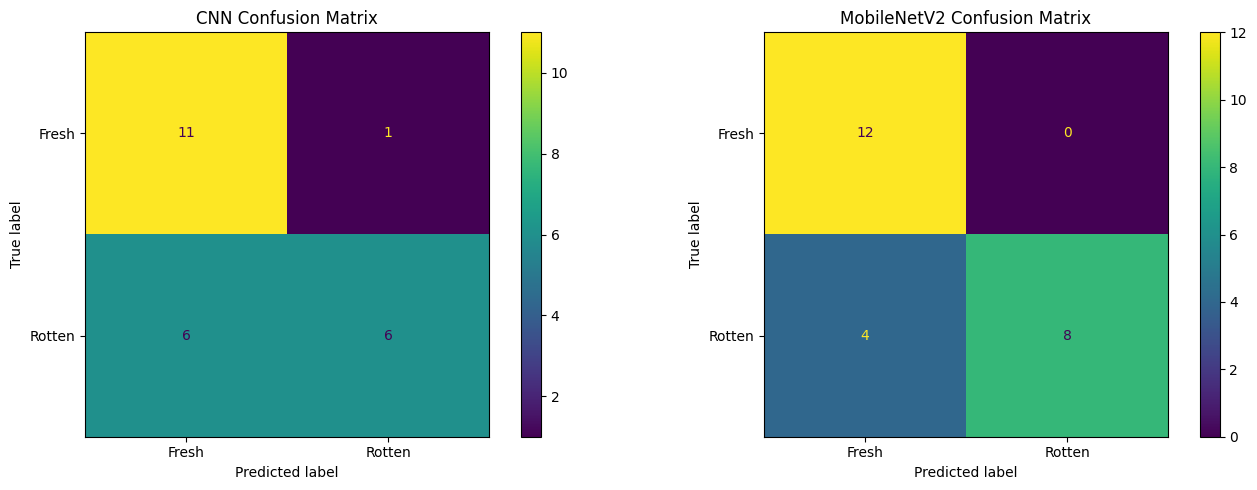

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CNN confusion matrix
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

disp_cnn = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=['Fresh', 'Rotten']
)

disp_cnn.plot(ax=axes[0])

axes[0].set_title('CNN Confusion Matrix')

# MobileNetV2 confusion matrix
cm_mobile = confusion_matrix(y_true, y_pred_mobile)

disp_mobile = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=['Fresh', 'Rotten']
)

disp_mobile.plot(ax=axes[1])

axes[1].set_title('MobileNetV2 Confusion Matrix')

plt.tight_layout()
plt.show()

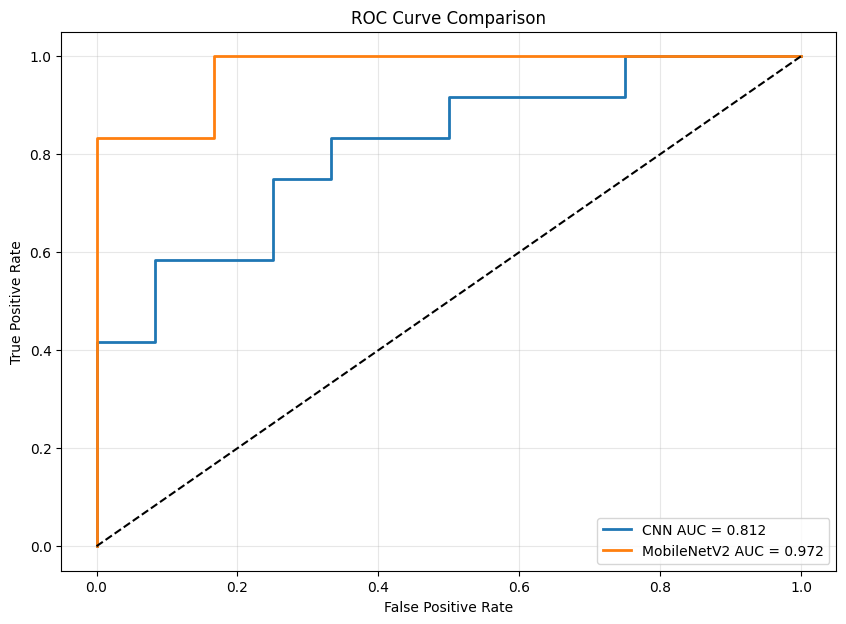

In [24]:
# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(
    y_true,
    y_pred_cnn_probs.ravel()
)
auc_cnn = auc(fpr_cnn, tpr_cnn)

# MobileNetV2 ROC
fpr_mobile, tpr_mobile, _ = roc_curve(
    y_true,
    y_pred_mobile_probs.ravel()
)
auc_mobile = auc(fpr_mobile, tpr_mobile)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_cnn,
    tpr_cnn,
    label=f'CNN AUC = {auc_cnn:.3f}',
    linewidth=2
)

plt.plot(
    fpr_mobile,
    tpr_mobile,
    label=f'MobileNetV2 AUC = {auc_mobile:.3f}',
    linewidth=2
)

plt.plot([0, 1], [0, 1], 'k--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [25]:
print("CNN CLASSIFICATION REPORT:")

print(classification_report(
    y_true,
    y_pred_cnn,
    target_names=['Fresh', 'Rotten']
))


print("MOBILENETV2 CLASSIFICATION REPORT:")

print(classification_report(
    y_true,
    y_pred_mobile,
    target_names=['Fresh', 'Rotten']
))


CNN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Fresh       0.65      0.92      0.76        12
      Rotten       0.86      0.50      0.63        12

    accuracy                           0.71        24
   macro avg       0.75      0.71      0.70        24
weighted avg       0.75      0.71      0.70        24

MOBILENETV2 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Fresh       0.75      1.00      0.86        12
      Rotten       1.00      0.67      0.80        12

    accuracy                           0.83        24
   macro avg       0.88      0.83      0.83        24
weighted avg       0.88      0.83      0.83        24



In [26]:
print("PERFORMANCE COMPARISON TABLE")

print("{:<15} {:<12} {:<12} {:<12} {:<12}".format(
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
))

print("-" * 65)

print("{:<15} {:<12} {:<12} {:<12} {:<12}".format(
    'CNN',
    f'{cnn_accuracy:.4f}',
    f'{cnn_precision:.4f}',
    f'{cnn_recall:.4f}',
    f'{cnn_f1:.4f}'
))

print("{:<15} {:<12} {:<12} {:<12} {:<12}".format(
    'MobileNetV2',
    f'{mobilenet_accuracy:.4f}',
    f'{mobile_precision:.4f}',
    f'{mobile_recall:.4f}',
    f'{mobile_f1:.4f}'
))

PERFORMANCE COMPARISON TABLE
Model           Accuracy     Precision    Recall       F1-Score    
-----------------------------------------------------------------
CNN             0.7083       0.8571       0.5000       0.6316      
MobileNetV2     0.8333       1.0000       0.6667       0.8000      


In [27]:
cnn_model.save('cnn_fruit_classifier.keras')

mobilenet_model.save('mobilenetv2_fruit_classifier.keras')

print("\n Models Saved Successfully")
print("1. cnn_fruit_classifier.keras")
print("2. mobilenetv2_fruit_classifier.keras")


 Models Saved Successfully
1. cnn_fruit_classifier.keras
2. mobilenetv2_fruit_classifier.keras


In [28]:
# SIMPLIFIED VERIFICATION CODE (Run after models are loaded)
from sklearn.metrics import accuracy_score, confusion_matrix

# Get true labels
y_true = test_data.labels

# Get predictions
y_pred_cnn_probs = cnn_model.predict(test_data, verbose=0)
y_pred_cnn = (y_pred_cnn_probs > 0.5).astype(int).flatten()

y_pred_mobile_probs = mobilenet_model.predict(test_data, verbose=0)
y_pred_mobile = (y_pred_mobile_probs > 0.5).astype(int).flatten()

# Calculate accuracies
cnn_acc = accuracy_score(y_true, y_pred_cnn)
mobile_acc = accuracy_score(y_true, y_pred_mobile)

print(f"CNN Accuracy: {cnn_acc:.4f} ({int(cnn_acc*24)}/24 correct)")
print(f"MobileNetV2 Accuracy: {mobile_acc:.4f} ({int(mobile_acc*24)}/24 correct)")

# Confusion matrices
print("\nCNN Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_cnn))

print("\nMobileNetV2 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_mobile))

CNN Accuracy: 0.7083 (17/24 correct)
MobileNetV2 Accuracy: 0.8333 (20/24 correct)

CNN Confusion Matrix:
[[11  1]
 [ 6  6]]

MobileNetV2 Confusion Matrix:
[[12  0]
 [ 4  8]]


In [29]:
# GET ALL CORRECTED METRICS
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# CNN Metrics
cnn_precision = precision_score(y_true, y_pred_cnn)
cnn_recall = recall_score(y_true, y_pred_cnn)
cnn_f1 = f1_score(y_true, y_pred_cnn)

# MobileNetV2 Metrics
mobile_precision = precision_score(y_true, y_pred_mobile)
mobile_recall = recall_score(y_true, y_pred_mobile)
mobile_f1 = f1_score(y_true, y_pred_mobile)

print("="*50)
print("CORRECTED PERFORMANCE METRICS")
print("="*50)

print("\nCNN METRICS:")
print(f"  Accuracy:  {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")
print(f"  Precision: {cnn_precision:.4f}")
print(f"  Recall:    {cnn_recall:.4f}")
print(f"  F1-Score:  {cnn_f1:.4f}")

print("\nMOBILENETV2 METRICS:")
print(f"  Accuracy:  {mobile_acc:.4f} ({mobile_acc*100:.2f}%)")
print(f"  Precision: {mobile_precision:.4f}")
print(f"  Recall:    {mobile_recall:.4f}")
print(f"  F1-Score:  {mobile_f1:.4f}")

print("\n" + "="*50)
print("PERFORMANCE COMPARISON TABLE (USE THIS IN YOUR REPORT)")
print("="*50)
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*65)
print(f"{'CNN':<15} {cnn_acc:.4f}       {cnn_precision:.4f}       {cnn_recall:.4f}       {cnn_f1:.4f}")
print(f"{'MobileNetV2':<15} {mobile_acc:.4f}       {mobile_precision:.4f}       {mobile_recall:.4f}       {mobile_f1:.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORTS")
print("="*50)
print("\nCNN CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_cnn, target_names=['Fresh', 'Rotten']))

print("\nMOBILENETV2 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_mobile, target_names=['Fresh', 'Rotten']))

CORRECTED PERFORMANCE METRICS

CNN METRICS:
  Accuracy:  0.7083 (70.83%)
  Precision: 0.8571
  Recall:    0.5000
  F1-Score:  0.6316

MOBILENETV2 METRICS:
  Accuracy:  0.8333 (83.33%)
  Precision: 1.0000
  Recall:    0.6667
  F1-Score:  0.8000

PERFORMANCE COMPARISON TABLE (USE THIS IN YOUR REPORT)
Model           Accuracy     Precision    Recall       F1-Score    
-----------------------------------------------------------------
CNN             0.7083       0.8571       0.5000       0.6316
MobileNetV2     0.8333       1.0000       0.6667       0.8000

CLASSIFICATION REPORTS

CNN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Fresh       0.65      0.92      0.76        12
      Rotten       0.86      0.50      0.63        12

    accuracy                           0.71        24
   macro avg       0.75      0.71      0.70        24
weighted avg       0.75      0.71      0.70        24


MOBILENETV2 CLASSIFICATION REPORT:
              precision    